0 4.602514266967773 1.0010000467300415
500 0.005503667984157801 0.6885941028594971
1000 0.00032637393451295793 0.528444230556488
1500 0.0001567938452353701 0.501807689666748
2000 0.00013868592213839293 0.5001841187477112
2500 0.00013249574112705886 0.5001503229141235
3000 0.00014102460409048945 0.5001763701438904
3500 0.00011961671407334507 0.5001121759414673
4000 0.006944526452571154 0.5001010894775391
4500 0.00010845520591828972 0.5001005530357361


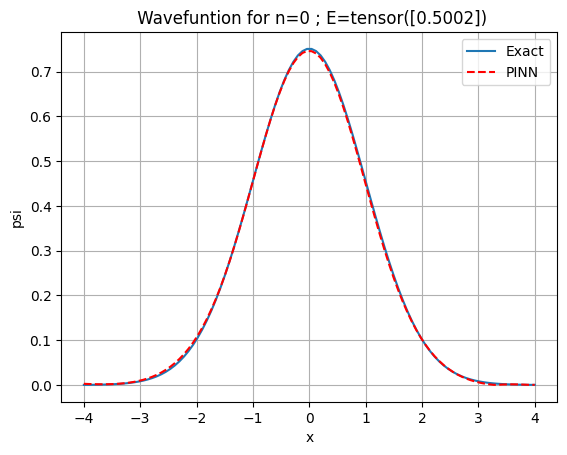

In [50]:
import torch 
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

x=torch.linspace(-4,4,100).reshape(-1,1)
x.requires_grad = True


model=nn.Sequential(
    nn.Linear(1,64),
    nn.Tanh(),
    nn.Linear(64,64),
    nn.Tanh(),
    nn.Linear(64,64),
    nn.Tanh(),
    nn.Linear(64,1),
)

def derivative(y,x):
    return torch.autograd.grad(y,x,grad_outputs=torch.ones_like(y),create_graph=True)[0]

E=nn.Parameter(torch.tensor([1.0]))
optimizer= optim.Adam(list(model.parameters())+[E],lr=0.001)
for i in range (5000):
    optimizer.zero_grad()
    V=0.5*(x**2)
    psi=model(x)
    psi_1 = torch.autograd.grad(psi,x,grad_outputs=torch.ones_like(psi),create_graph=True)[0]
    psi_2 = torch.autograd.grad(psi_1,x,grad_outputs=torch.ones_like(psi_1),create_graph=True)[0]

    # loss 
    Lpde=torch.mean(( -0.5*psi_2+ V*psi - E*psi)**2)
    dx=x[1]-x[0]
    Lnorm= ((torch.sum(psi**2))*dx-1)**2
    xb=torch.tensor([[-4.0],[4.0]])
    psi_b=model(xb)
    loss_bc=torch.mean(psi_b**2)
    loss = Lpde+10*Lnorm+loss_bc
    loss.backward()
    optimizer.step()

    if i%500==0:
        print(i,loss.item(),E.item())

with torch.no_grad():
    psi=model(x)

u=x.detach().numpy()
v=np.abs(psi.detach().numpy())

x_exact=np.linspace(-4,4,100)
y_exact= np.pi**(-0.25)*np.exp(-(x_exact**2)/2)
plt.plot(x_exact,y_exact,label='Exact')
plt.plot(u,v,color='red',label='PINN',linestyle='--')
plt.xlabel('x')
plt.ylabel('psi')
plt.title(f' Wavefuntion for n=0 ; E={E.detach()}')
plt.legend()
plt.grid(True)
plt.show()


    
    
               
    

    

    

               
    


        
        
    
    

 

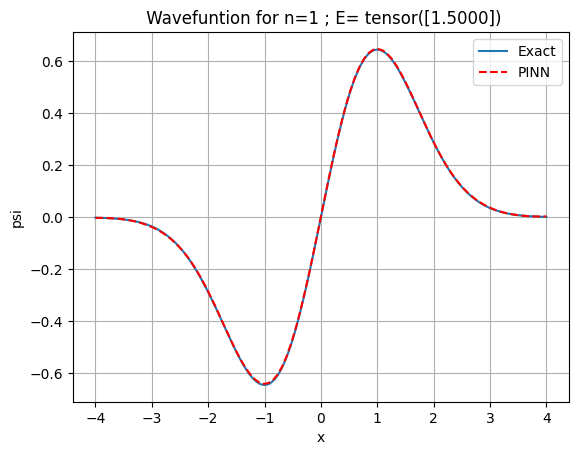

In [51]:
psi=model(x).detach()
model1 = nn.Sequential(
    nn.Linear(1,64),
    nn.Tanh(),
    nn.Linear(64,64),
    nn.Tanh(),
    nn.Linear(64,64),
    nn.Tanh(),
    nn.Linear(64,1))

E1=nn.Parameter(torch.tensor([1.0]))
optimizer=optim.Adam(list(model1.parameters())+ [E1],lr=0.001)
for i in range(5000):
    optimizer.zero_grad()
    V=0.5*(x**2)
    psi1=model1(x)
    psi_1 = torch.autograd.grad(psi1,x,grad_outputs=torch.ones_like(psi1),create_graph=True)[0]
    psi_2 = torch.autograd.grad(psi_1,x,grad_outputs=torch.ones_like(psi_1),create_graph=True)[0]

    # loss 
    Lpde=torch.mean(( -0.5*psi_2+ V*psi1 - E1*psi1)**2)
    dx=x[1]-x[0]
    Lnorm= ((torch.sum(psi1**2))*dx-1)**2
    xb=torch.tensor([[-4.0],[4.0]])
    psi_b=model1(xb)
    loss_bc=torch.mean(psi_b**2)
    lExcited=(torch.sum(psi*psi1)*dx)**2
    loss = Lpde+10*Lnorm+loss_bc+lExcited
    loss.backward()
    optimizer.step()


with torch.no_grad():
    psi1=model1(x)

u=x.detach().numpy()
v=psi1.detach().numpy()
x_exact = np.linspace(-4, 4, 200)

psi_exact = np.sqrt(2) * np.pi**(-0.25) * x_exact * np.exp(-x_exact**2 / 2)

plt.plot(x_exact, psi_exact,label='Exact')
plt.plot(u,v,color='red',linestyle="--",label='PINN')
plt.xlabel('x')
plt.ylabel('psi')
plt.title(f' Wavefuntion for n=1 ; E= {E1.detach()}')
plt.legend()
plt.grid(True)
plt.show()

    
    


    


    

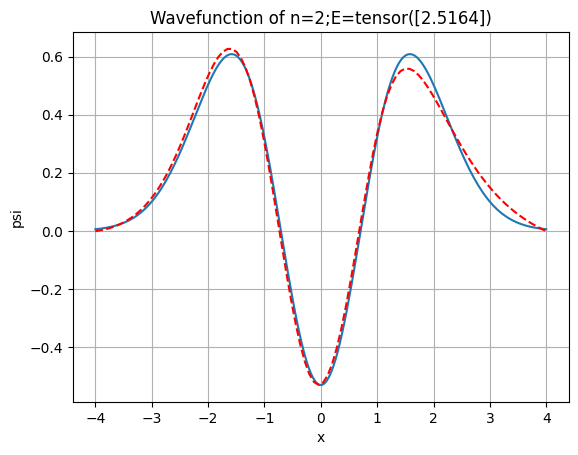

In [52]:
psi=model(x).detach()
model2 = nn.Sequential(
    nn.Linear(1,64),
    nn.Tanh(),
    nn.Linear(64,64),
    nn.Tanh(),
    nn.Linear(64,64),
    nn.Tanh(),
    nn.Linear(64,1))

E2=nn.Parameter(torch.tensor([1.0]))
optimizer=optim.Adam(list(model2.parameters())+ [E2],lr=0.001)
for i in range(5000):
    optimizer.zero_grad()
    V=0.5*(x**2)
    psi2=model2(x)
    psi_1 = torch.autograd.grad(psi2,x,grad_outputs=torch.ones_like(psi2),create_graph=True)[0]
    psi_2 = torch.autograd.grad(psi_1,x,grad_outputs=torch.ones_like(psi_1),create_graph=True)[0]

    # loss 
    dx=x[1]-x[0]
    Lorth0 = (torch.sum(psi * psi2) * dx)**2
    Lorth1 = (torch.sum(psi1 * psi2) * dx)**2
    lorth = Lorth0 + Lorth1
    Lpde=torch.mean(( -0.5*psi_2+ V*psi2 - E2*psi2)**2)
    Lnorm= ((torch.sum(psi2**2))*dx-1)**2
    xb=torch.tensor([[-4.0],[4.0]])
    psi_b=model2(xb)
    loss_bc=torch.mean(psi_b**2)
    loss = Lpde+100*Lnorm+50*loss_bc+100*lorth
    loss.backward()
    optimizer.step()


with torch.no_grad():
    psi2=model2(x)

u=x.detach().numpy()
v=psi2.detach().numpy()
x_exact = np.linspace(-4, 4, 200)

psi_exact = ((2*x_exact**2 - 1)* np.exp(-x_exact**2/2)/(np.sqrt(2)*np.pi**0.25))
plt.plot(x_exact, psi_exact,label='Exact')
plt.plot(u,v,color='red',linestyle="--",label='PINN')
plt.xlabel('x')
plt.ylabel('psi')
plt.title(f'Wavefunction of n=2;E={E2.detach()}')
plt.grid(True)
plt.show()
dx = x[1] - x[0]

    
    


    


    